In [27]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import insightface
import random
from datetime import datetime

In [2]:
models = ['/home/sho/.insightface/models/buffalo_l/w600k_r50.onnx']
algos = ['brute-force', 'hnsw', 'fvs']

for model in models:
    # get df with embeddings
    for algo in algos:
        if algo == 'brute-force':
            # accpetence_rates = run_brute_force()
            pass
        elif algo == 'hnsw':
            # accpetence_rates = run_hnsw()
            pass
        elif algo == 'fvs':
            # accpetence_rates = run_fvs()
            pass






In [3]:
df = pd.read_pickle("./embeddings-0312.pkl")

print(type(df['embedding'].iloc[0]))  # <class 'numpy.ndarray'>
is_array_col = df['embedding'].apply(lambda x: isinstance(x, np.ndarray))
print(is_array_col.value_counts())

# convert back to float32
df['embedding'] = df['embedding'].apply(lambda x: x.astype(np.float32))

<class 'numpy.ndarray'>
embedding
True    13195
Name: count, dtype: int64


In [4]:
df.head()

,name,ID,embedding,embedding type,embedding dtype,embedding_size,image_name,filepath
0,AJ_Cook,0,"[-0.3419863, 0.6712041, -1.2866051, 0.60350394...",<class 'numpy.ndarray'>,float32,512,AJ_Cook_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
1,AJ_Lamas,1,"[0.059667192, 0.076293096, 1.3340704, 1.245711...",<class 'numpy.ndarray'>,float32,512,AJ_Lamas_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
2,Aaron_Eckhart,2,"[1.2447274, -0.9747005, 1.2987878, 0.46920043,...",<class 'numpy.ndarray'>,float32,512,Aaron_Eckhart_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
3,Aaron_Guiel,3,"[-0.17151171, -1.2514898, -0.38039768, -0.0818...",<class 'numpy.ndarray'>,float32,512,Aaron_Guiel_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
4,Aaron_Patterson,4,"[0.41729146, -0.24729499, -0.86146384, -2.1820...",<class 'numpy.ndarray'>,float32,512,Aaron_Patterson_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...


In [5]:
df.shape

(13195, 8)

In [6]:
df.columns

Index(['name', 'ID', 'embedding', 'embedding type', 'embedding dtype',
       'embedding_size', 'image_name', 'filepath'],
      dtype='object')

In [3]:
df['embedding'].iloc[0].dtype

dtype('float32')

In [15]:
detector = insightface.model_zoo.get_model('/home/sho/.insightface/models/buffalo_l/w600k_r50.onnx')


/home/sho/anaconda3/envs/face-gen-notebook/lib/python3.13/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:118: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


In [7]:
df.head()

,name,ID,embedding,embedding type,embedding dtype,embedding_size,image_name,filepath
0,AJ_Cook,0,"[-0.3419863, 0.6712041, -1.2866051, 0.60350394...",<class 'numpy.ndarray'>,float32,512,AJ_Cook_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
1,AJ_Lamas,1,"[0.059667192, 0.076293096, 1.3340704, 1.245711...",<class 'numpy.ndarray'>,float32,512,AJ_Lamas_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
2,Aaron_Eckhart,2,"[1.2447274, -0.9747005, 1.2987878, 0.46920043,...",<class 'numpy.ndarray'>,float32,512,Aaron_Eckhart_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
3,Aaron_Guiel,3,"[-0.17151171, -1.2514898, -0.38039768, -0.0818...",<class 'numpy.ndarray'>,float32,512,Aaron_Guiel_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
4,Aaron_Patterson,4,"[0.41729146, -0.24729499, -0.86146384, -2.1820...",<class 'numpy.ndarray'>,float32,512,Aaron_Patterson_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...


In [ ]:
query_idx = random.randint(0, len(df) - 1)
query_emb = df['embedding'].iloc[query_idx]
name = df.iloc[query_idx]['name']
person_id = df.iloc[query_idx]['ID']

print(query_idx, name, person_id)

# groupby person id
df[df.ID == person_id].shape[0]

11242 Sammy_Sosa 4893


(2, 8)

In [ ]:
def get_top_k(top_k, similarities, query_person_id):
    top_k_pos = 0
    top_k_indices = np.argsort(similarities)[::-1][:top_k]
    top_k_scores = [similarities[i] for i in top_k_indices]
    
    for t in top_k_indices:
        t_person_id = df.iloc[t]['ID']
        if t_person_id == query_person_id:
            top_k_pos += 1
            break
    
    return 

In [35]:
top_1_pos = 0
top_3_pos = 0
top_10_pos = 0
total = 0
top_1_failures = []
top_3_failures = []
top_10_failures = []
search_time = []

for j in tqdm(range(len(df))):
    """if j >= 100:
        break"""

    query_idx = j
    query_emb = df['embedding'].iloc[query_idx]
    query_person_id = df.iloc[query_idx]['ID']
    query_name = df.iloc[query_idx]['name']

    v_cnt = df[df.ID == query_person_id].shape[0]
    if v_cnt == 1:
        continue
    total += 1

    #print(query_idx, query_person_id, query_name)
    #print("value_counts: ", v_cnt)
    

    # sim scores
    similarities = []

    start_time = datetime.now()
    for i in range(len(df)):
        if i == query_idx:
            continue
        emb = df['embedding'].iloc[i]
        sim = detector.compute_sim(query_emb, emb)
        similarities.append(sim)
    
    #print("top 10:", np.argsort(similarities)[::-1][:10])

    top_10_lst = np.argsort(similarities)[::-1][:10]

    ## === TOP-1 Evaluation ===
    
    top_k_indices = np.argsort(similarities)[::-1][:1]
    top_k_scores = [similarities[i] for i in top_10_lst]

    if df.iloc[top_k_indices[0]]['ID'] == query_person_id:
        top_1_pos += 1

    else:
        top_1_failures.append({
            'query_idx': query_idx,
            'query_id': query_person_id,
            'query_name': query_name,
            'top_k_indices': top_10_lst.tolist(), 
            'top_k_scores':top_k_scores
        })
    end_time = datetime.now()
    search_time.append((end_time - start_time).total_seconds())

    ## === TOP-3 Evaluation ===
    top_k_indices = np.argsort(similarities)[::-1][:3]
    top_k_scores = [similarities[i] for i in top_10_lst]
    top_k_ids = [df.iloc[i]['ID'] for i in top_k_indices]
    if query_person_id in top_k_ids:
        top_3_pos += 1
    else:
        top_3_failures.append({
            'query_idx': query_idx,
            'query_id': query_person_id,
            'query_name': query_name,
            'top_k_indices': top_10_lst.tolist(), 
            'top_k_scores':top_k_scores
        })

    ## === TOP-10 Evaluation ===
    top_k_indices = np.argsort(similarities)[::-1][:10]
    top_k_scores = [similarities[i] for i in top_10_lst]
    top_k_ids = [df.iloc[i]['ID'] for i in top_k_indices]
    if query_person_id in top_k_ids:
        top_10_pos += 1
    else:
        top_10_failures.append({
            'query_idx': query_idx,
            'query_id': query_person_id,
            'query_name': query_name,
            'top_k_indices': top_k_indices.tolist(),
            'top_k_scores:': top_k_scores
        })

## Final Reporting
print("Total query attempts:", total)
print(f"Top-1 Accuracy: {top_1_pos}/{total} = {top_1_pos/total:.4f}")
print(f"Top-3 Accuracy: {top_3_pos}/{total} = {top_3_pos/total:.4f}")
print(f"Top-10 Accuracy: {top_10_pos}/{total} = {top_10_pos/total:.4f}")
print(f"Top-1 Failures: {len(top_1_failures)}")
print(f"Top-3 Failures: {len(top_3_failures)}")
print(f"Top-10 Failures: {len(top_10_failures)}")
print(f"Average Search Time: {np.mean(search_time)}")


print("done")

  0%|          | 0/13195 [00:00<?, ?it/s]

100%|██████████| 13195/13195 [38:37<00:00,  5.69it/s]

Total query attempts: 9133
Top-1 Accuracy: 8928/9133 = 0.9776
Top-3 Accuracy: 8999/9133 = 0.9853
Top-10 Accuracy: 9001/9133 = 0.9855
Top-1 Failures: 205
Top-3 Failures: 134
Top-10 Failures: 132
Average Search Time: 0.2491423753421658
done


# hnsw

In [20]:
import hnswlib
import pickle

# === Load embeddings and metadata ===
with open("./embeddings-0312.pkl", "rb") as f:
    df = pickle.load(f)

embedding_matrix = np.stack(df['embedding'].values)
dim = embedding_matrix.shape[1]
print("dim", dim)
print("emb shape", embedding_matrix.shape)

# Build the index
index = hnswlib.Index(space='cosine', dim=dim)
index.init_index(max_elements=len(embedding_matrix), ef_construction=200, M=16)

# Add embeddings to the index
index.add_items(embedding_matrix, np.arange(len(embedding_matrix)))

# Save the index to a binary file
index.save_index("embedding_index_hnsw.bin")


dim 512
emb shape (13195, 512)


In [36]:

"""# === Load hnswlib index ===
index = hnswlib.Index(space='cosine', dim=dim)
index.load_index("embedding_index_hnsw.bin")
index.set_ef(50)"""

# === Evaluation counters ===
top_1_pos = 0
top_3_pos = 0
top_10_pos = 0
total = 0

top_1_failures = []
top_3_failures = []
top_10_failures = []
search_time = []

# === Evaluation loop ===
for query_idx in tqdm(range(len(df)), desc="Evaluating search accuracy"):
    query_person_id = df.iloc[query_idx]['ID']
    query_name = df.iloc[query_idx]['name']
    
    # Skip if only one image for this person
    if df[df.ID == query_person_id].shape[0] == 1:
        continue
    
    total += 1
    #print("query person id: ", query_person_id)
    #print("query name: ", query_name)
    query_embedding = embedding_matrix[query_idx].reshape(1, -1)


    df_copy = df.copy()
    #print("before drop, df copy shape:", df_copy.shape)
    df_copy.drop(query_idx, inplace=True)
    #print("after drop, df copy shape:", df_copy.shape)
    
    embedding_matrix_drop = np.stack(df_copy['embedding'].values)
    
    start_time = datetime.now()
    # Build the index
    index_drop = hnswlib.Index(space='cosine', dim=dim)
    index_drop.init_index(max_elements=len(embedding_matrix_drop), ef_construction=200, M=16)

    # Add embeddings to the index
    index_drop.add_items(embedding_matrix_drop, np.arange(len(embedding_matrix_drop)))
    
    # Search top 10 neighbors (we'll slice top1/top3 from it)
    top_k = 10
    labels, distances = index_drop.knn_query(query_embedding, k=top_k)

    top_k_indices = labels[0]
    top_k_ids = [df_copy.iloc[idx]['ID'] for idx in top_k_indices]

    ## Top-1 evaluation
    if top_k_ids[0] == query_person_id:
        top_1_pos += 1
    else:
        top_1_failures.append({
            'query_idx': query_idx,
            'query_id': query_person_id,
            'query_name': query_name,
            'top_k_indices': top_k_indices[:1].tolist(),
            'top_k_ids': top_k_ids[:1],
            'top_k_names': [df_copy.iloc[i]['name'] for i in top_k_indices[:1]]
        })

    end_time = datetime.now()
    search_time.append((end_time - start_time).total_seconds())

    ## Top-3 evaluation
    if query_person_id in top_k_ids[:3]:
        top_3_pos += 1
    else:
        top_3_failures.append({
            'query_idx': query_idx,
            'query_id': query_person_id,
            'query_name': query_name,
            'top_k_indices': top_k_indices[:3].tolist(),
            'top_k_ids': top_k_ids[:3],
            'top_k_names': [df_copy.iloc[i]['name'] for i in top_k_indices[:3]]
        })

    ## Top-10 evaluation
    if query_person_id in top_k_ids[:10]:
        top_10_pos += 1
    else:
        top_10_failures.append({
            'query_idx': query_idx,
            'query_id': query_person_id,
            'query_name': query_name,
            'top_k_indices': top_k_indices.tolist(),
            'top_k_ids': top_k_ids,
            'top_k_names': [df_copy.iloc[i]['name'] for i in top_k_indices]
        })

    # Optional early stopping (e.g., for testing)
    """if query_idx == 1000:
        break"""

# === Final report ===
print("\n✅ Evaluation Summary:")
print(f"Total evaluated queries: {total}")
print(f"Top-1 accuracy: {top_1_pos}/{total} = {top_1_pos/total:.4f}")
print(f"Top-3 accuracy: {top_3_pos}/{total} = {top_3_pos/total:.4f}")
print(f"Top-10 accuracy: {top_10_pos}/{total} = {top_10_pos/total:.4f}")
print(f"Top-1 failures: {len(top_1_failures)}")
print(f"Top-3 failures: {len(top_3_failures)}")
print(f"Top-10 failures: {len(top_10_failures)}")
print(f"Average Search Time HNSW: {np.mean(search_time)}")

Evaluating search accuracy:   0%|          | 0/13195 [00:00<?, ?it/s]

Evaluating search accuracy: 100%|██████████| 13195/13195 [41:25<00:00,  5.31it/s]


✅ Evaluation Summary:
Total evaluated queries: 9133
Top-1 accuracy: 8520/9133 = 0.9329
Top-3 accuracy: 8586/9133 = 0.9401
Top-10 accuracy: 8587/9133 = 0.9402
Top-1 failures: 613
Top-3 failures: 547
Top-10 failures: 546
Average Search Time HNSW: 0.22572972079272965


In [60]:
df.iloc[34]['ID']

np.int64(20)

In [61]:
for i in top_1_failures[0]['top_k_indices']:
    id = df.iloc[i]['ID']
    print(id)

4551
20
20
20
20
20
20
20
20
20


In [68]:
top_1_failures

[]

In [53]:
top_1_failures[0]['top_k_indices']

[10462, 37, 31, 43, 44, 39, 35, 42, 47, 41]

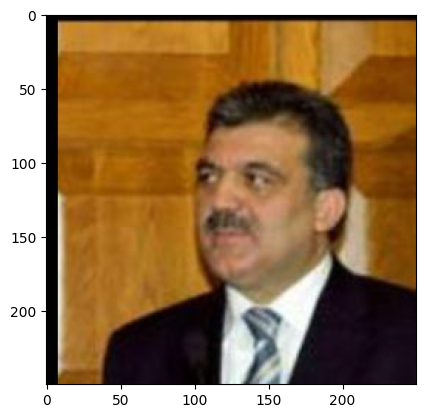

In [52]:
import cv2
import matplotlib.pyplot as plt

read_img = cv2.imread(df.iloc[34]['filepath'])

plt.imshow(read_img[:,:,::-1])
plt.show()

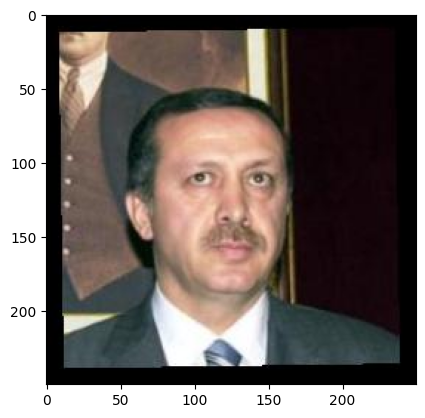

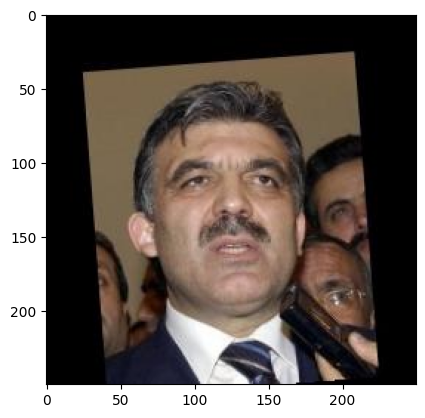

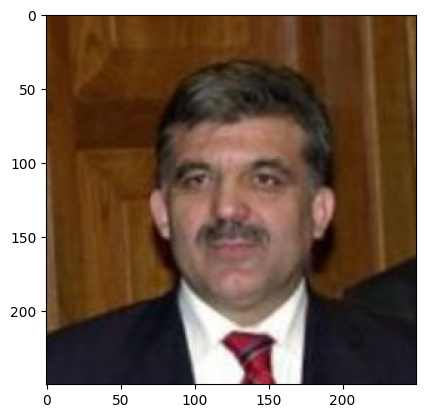

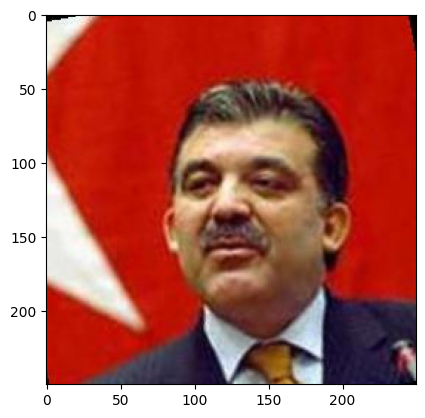

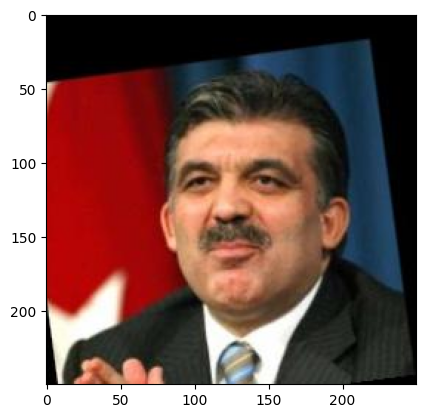

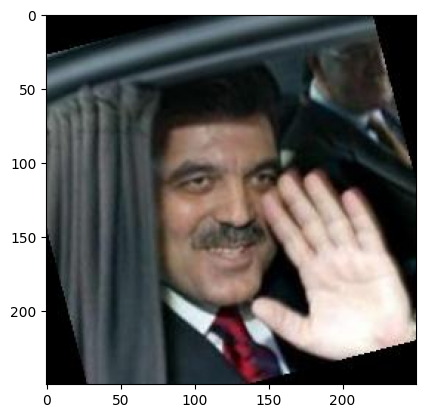

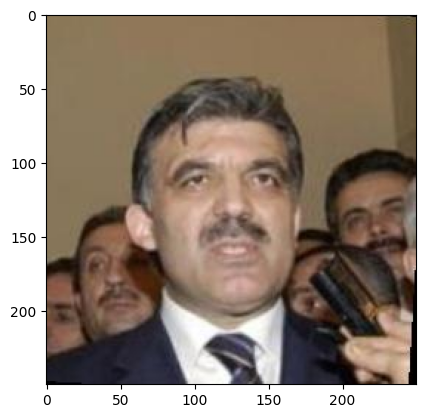

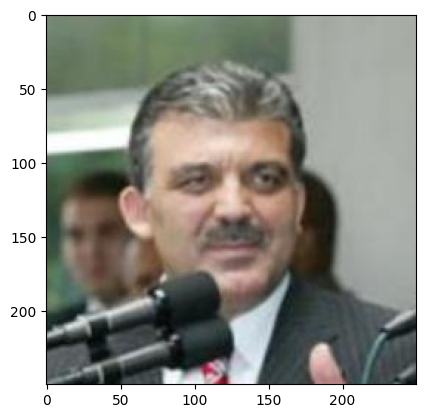

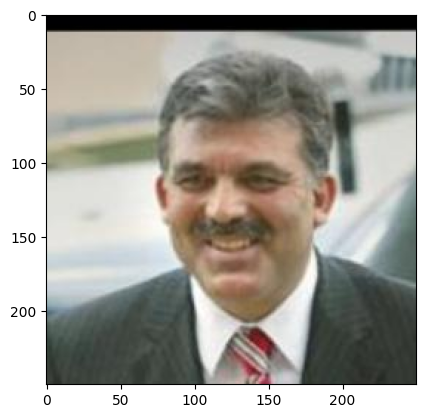

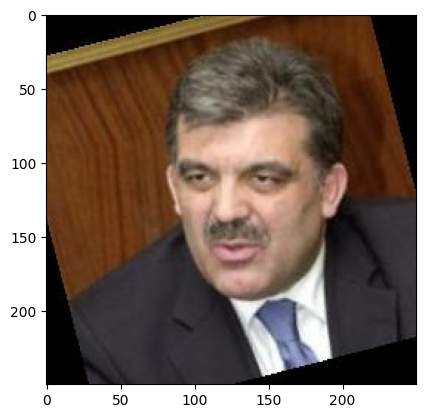

In [55]:
for i in top_1_failures[0]['top_k_indices']:
    read_img = cv2.imread(df.iloc[i]['filepath'])

    plt.imshow(read_img[:,:,::-1])
    plt.show()

In [47]:
df.head()

,name,ID,embedding,embedding type,embedding dtype,embedding_size,image_name,filepath
0,AJ_Cook,0,"[-0.3419863, 0.6712041, -1.2866051, 0.60350394...",<class 'numpy.ndarray'>,float32,512,AJ_Cook_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
1,AJ_Lamas,1,"[0.059667192, 0.076293096, 1.3340704, 1.245711...",<class 'numpy.ndarray'>,float32,512,AJ_Lamas_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
2,Aaron_Eckhart,2,"[1.2447274, -0.9747005, 1.2987878, 0.46920043,...",<class 'numpy.ndarray'>,float32,512,Aaron_Eckhart_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
3,Aaron_Guiel,3,"[-0.17151171, -1.2514898, -0.38039768, -0.0818...",<class 'numpy.ndarray'>,float32,512,Aaron_Guiel_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
4,Aaron_Patterson,4,"[0.41729146, -0.24729499, -0.86146384, -2.1820...",<class 'numpy.ndarray'>,float32,512,Aaron_Patterson_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...


In [ ]:
"""top1_match_found = False
    # top 1
    top_k = 1
    top_k_indices = np.argsort(similarities)[::-1][:top_k]
    top_k_scores = [similarities[i] for i in top_k_indices]

    for t in top_k_indices:
        t_person_id = df.iloc[t]['ID']
        #print("top 1", t, "person_id:", t_person_id, "name: ", df.iloc[t]['name'])
        if t_person_id == query_person_id:
            top_1_pos += 1
            top1_match_found = True
            break

        if not top1_match_found:
            top_1_failures.append({'query_idx':query_idx, 'person_id':t_person_id})


    # top 3
    top_k = 3
    top_k_indices = np.argsort(similarities)[::-1][:top_k]
    top_k_scores = [similarities[i] for i in top_k_indices]
    
    for t in top_k_indices:
        t_person_id = df.iloc[t]['ID']
        #print("top 3", t, "person_id:", t_person_id, "name: ", df.iloc[t]['name'])
        if t_person_id == query_person_id:
            top_3_pos += 1
            break


    # top 10
    top_k = 10
    top_k_indices = np.argsort(similarities)[::-1][:top_k]
    top_k_scores = [similarities[i] for i in top_k_indices]
    
    for t in top_k_indices:
        t_person_id = df.iloc[t]['ID']
        if t_person_id == query_person_id:
            top_10_pos += 1
            brea
            

    #print("top k:", top_1_pos, top_3_pos)


    
print("total query: ", total)

r1 = (top_1_pos*1.0)/(total)
print("top 1 rate:", r1)

r3 = (top_3_pos*1.0)/(total)
print("top 3 rate:", r3)

r10 = (top_10_pos*1.0)/(total)
print("top 3 rate:", r10)"""

In [41]:
top_1_failures

[{'query_idx': 34, 'person_id': np.int64(4551)},
 {'query_idx': 40, 'person_id': np.int64(4551)}]

In [6]:
print("hello")

hello


# compare_faces

In [10]:
from insightface.app import FaceAnalysis

In [11]:
app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])  # Use 'CUDAExecutionProvider' for GPU
app.prepare(ctx_id=-1)  # ctx_id=-1 for CPU, 0 for GPU


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (64

In [12]:
def compare_faces(emb1, emb2, threshold=0.65): # Adjust this threshold according to your usecase.
    """Compare two embeddings using cosine similarity"""
    similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
    return similarity, similarity > threshold

In [24]:
emb1 = df['embedding'].iloc[5]
emb2 = df['embedding'].iloc[8]

In [25]:
similarity_score, is_same_person = compare_faces(emb1, emb2)

print(f"Similarity Score: {similarity_score:.4f}")
print(f"Same person? {'YES' if is_same_person else 'NO'}")

Similarity Score: 0.7743
Same person? YES


In [21]:
df.head(10)

,name,ID,embedding,embedding type,embedding dtype,embedding_size,image_name,filepath
0,AJ_Cook,0,"[-0.3419863, 0.6712041, -1.2866051, 0.60350394...",<class 'numpy.ndarray'>,float32,512,AJ_Cook_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
1,AJ_Lamas,1,"[0.059667192, 0.076293096, 1.3340704, 1.245711...",<class 'numpy.ndarray'>,float32,512,AJ_Lamas_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
2,Aaron_Eckhart,2,"[1.2447274, -0.9747005, 1.2987878, 0.46920043,...",<class 'numpy.ndarray'>,float32,512,Aaron_Eckhart_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
3,Aaron_Guiel,3,"[-0.17151171, -1.2514898, -0.38039768, -0.0818...",<class 'numpy.ndarray'>,float32,512,Aaron_Guiel_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
4,Aaron_Patterson,4,"[0.41729146, -0.24729499, -0.86146384, -2.1820...",<class 'numpy.ndarray'>,float32,512,Aaron_Patterson_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
5,Aaron_Peirsol,5,"[-0.0011550486, -1.3685023, -0.04704857, 0.508...",<class 'numpy.ndarray'>,float32,512,Aaron_Peirsol_0002.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
6,Aaron_Peirsol,5,"[-0.3687567, -1.6064845, 1.2511823, -0.3996735...",<class 'numpy.ndarray'>,float32,512,Aaron_Peirsol_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
7,Aaron_Peirsol,5,"[0.11826757, 0.22257553, 0.58508146, -0.420746...",<class 'numpy.ndarray'>,float32,512,Aaron_Peirsol_0004.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
8,Aaron_Peirsol,5,"[0.79239154, -0.7837923, 0.58785397, 0.9641951...",<class 'numpy.ndarray'>,float32,512,Aaron_Peirsol_0003.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
9,Aaron_Pena,6,"[0.36856884, -0.29397953, -0.80316275, -0.6318...",<class 'numpy.ndarray'>,float32,512,Aaron_Pena_0001.jpg,/home/sho/Insightface-Face-Recognition/img/LFW...
